In [1]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "Lykon/dreamshaper-8"#"runwayml/stable-diffusion-v1-5"   Lykon/dreamshaper-8

# 1. Load the model in standard float32 (Removes the torch_dtype flag)
# This completely bypasses the GTX 1660 Ti "black image / NaN" hardware bug.
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    use_safetensors=True,
    safety_checker=None, # Disabling this saves extra VRAM and prevents false positives
    requires_safety_checker=False
)

# 2. MAXIMUM VRAM OPTIMIZATIONS FOR FLOAT32

# Optimization A: Sequential Layer Offloading (The 1660 Ti Lifesaver)
# Instead of offloading whole models, this offloads individual layers to CPU RAM
# right after they compute. It drastically reduces VRAM spikes.
pipe.enable_sequential_cpu_offload()

# Optimization B: Strict Attention Slicing
# Forces the attention math to be done in the smallest possible chunks (slice size of 1)
pipe.enable_attention_slicing(1)

# Optimization C: VAE Slicing
pipe.enable_vae_slicing()

# # 3. Generate the Asset
# print("Generating asset in standard precision (This will be slower, but accurate)...")
# prompt = "a high quality modern flyer background for a coffee shop, minimal, clean"
#
# # Lowered to 20 steps to save time during this slower offloaded generation
# image = pipe(prompt, num_inference_steps=25).images[0]
#
# image.save("print_asset_background.png")
# print("Image saved successfully!")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.
/media/edwardl.campbell/D/code/CanvasBot/.venv/lib/python3.12/site-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(


In [2]:
# import os
# import torch
# from diffusers import FluxPipeline
# from diffusers.quantizers import PipelineQuantizationConfig
#
# model_id = "black-forest-labs/FLUX.1-schnell"
#
# # 1. Use PipelineQuantizationConfig for the correct class type
# quant_config = PipelineQuantizationConfig(
#     quant_backend="bitsandbytes_4bit",
#     quant_kwargs={
#         "bnb_4bit_compute_dtype": torch.bfloat16,
#         "bnb_4bit_quant_type": "nf4",
#     }
# )
#
# # 2. Load the pipeline
# # We remove device_map="auto" because sequential_cpu_offload handles placement
# pipe = FluxPipeline.from_pretrained(
#     model_id,
#     quantization_config=quant_config,
#     torch_dtype=torch.bfloat16,
#     token=os.environ.get("HF_TOKEN")
# )
#
# # 3. USE SEQUENTIAL OFFLOAD (Crucial for 6GB)
# # enable_model_cpu_offload() moves entire components, which may still OOM
# # if the transformer exceeds 6GB. Sequential offload moves layer-by-layer.
# pipe.enable_sequential_cpu_offload()
#
# # 4. Optional: VAE Slicing/Tiling to save more VRAM during decoding
# pipe.enable_vae_slicing()
# pipe.enable_vae_tiling()

In [3]:
# Proof of Concept: Multi-Agent System with LangGraph v19
#
# This version introduces deterministic text wrapping directly within the validator.
# Instead of forcing the LLM to guess how to break lines, the system does it automatically.

from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import List, Optional, Literal
import os
from PIL import Image, ImageDraw, ImageFont
from reportlab.pdfgen import canvas
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont

# --- Define Allowed Types ---
AllowedFonts = Literal['Helvetica', 'Helvetica-Bold', 'Times-Roman', 'Times-Bold', 'Courier', 'Montserrat-Black', 'Montserrat-Regular']
DesignCategories = Literal['flyer', 'poster', 'business_card', 'unsupported_style']

# --- Pydantic Models ---
class GatekeeperResult(BaseModel):
    category: DesignCategories = Field(..., description="The classified design category.")

from pydantic import BaseModel, Field
from typing import Literal, List

class TextBlock(BaseModel):
    role: Literal['headline', 'subtitle', 'body', 'cta'] = Field(...)
    content: str = Field(...)
    emphasis: Literal['none', 'script'] = 'none'
    vertical_zone: Literal['top', 'middle', 'bottom'] = 'middle' # NEW: Individual element zoning

class CopywritingResult(BaseModel):
    background_style: Literal['full_image', 'solid_color_with_photo', 'solid_color_text_only'] = Field(...)
    background_hex: str = Field(
        ...,
        description="A valid 6-character hex color code starting with '#' (e.g., '#FFC680', '#0072C6'). DO NOT use natural language color names."
    )
    visual_subject: str = Field(
        ...,
        description="EXTRACT VERBATIM: Copy the exact text from the user's prompt regarding the visuals, subjects, and colors. DO NOT SUMMARIZE. DO NOT TRUNCATE."
    )
    visual_style: Literal['photography', 'illustration', '3d_render', 'abstract'] = Field(...)
    text_scale: Literal['small', 'standard', 'large'] = 'standard'
    blocks: List[TextBlock] = Field(...)

class TextElement(BaseModel):
    type: Literal['text'] = 'text'
    text: str
    font: str = 'Poppins-Bold'
    size: int = 12
    x_pos: int = 0
    y_pos: int = 0
    rotation: Literal[0, 90] = 0
    color: str = '#000000'
    alignment: Literal['left', 'center', 'right'] = 'center'
    emphasis: Literal['none', 'script'] = 'none'
    vertical_zone: Literal['top', 'middle', 'bottom'] = 'middle' # NEW: Mapped from Copywriter
    lines: List[str] = []

class DesignLayout(BaseModel):
    spatial_reasoning: str = Field(...)
    horizontal_placement: Literal['left', 'center', 'right'] = 'center'
    width: int
    height: int
    bleed_margin: int = 9
    safe_zone_margin: int = 18
    background_image: str = Field(...)
    elements: List[TextElement] = Field(...)


class AgentState(BaseModel):
    prompt: str
    design_category: Optional[DesignCategories] = None
    structured_copy: Optional[CopywritingResult] = None
    image_path: Optional[str] = None
    layout: Optional[DesignLayout] = None
    validation_error: Optional[str] = None
    retry_count: int = 0


In [4]:
from typing import Literal
from pydantic import BaseModel
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from pathlib import Path

# 1. Update Pydantic model to allow your new modern fonts
class MyPdfConfig(BaseModel):
    # Literal enforces that only these specific strings can be used by the LLM
    font_choice: Literal['Poppins-Bold', 'Poppins-Regular', 'Caveat-Bold', 'Helvetica']

# Get the directory where your script/notebook is located
BASE_DIR = Path.cwd()

# Assuming you placed the new downloaded fonts directly in the notebook folder
FONT_FOLDER = BASE_DIR / 'fonts'

# 2. Function to register the files with ReportLab
def register_fonts():
    try:
        # pdfmetrics.registerFont(TTFont('NameInCode', 'ActualFilePath'))
        pdfmetrics.registerFont(TTFont('Poppins-Bold', FONT_FOLDER / 'Poppins-Bold.ttf'))
        pdfmetrics.registerFont(TTFont('Poppins-Regular', FONT_FOLDER / 'Poppins-Regular.ttf'))
        pdfmetrics.registerFont(TTFont('Caveat-Bold', FONT_FOLDER / 'Caveat-Bold.ttf'))
        print("Modern Canva-style fonts registered successfully.")
    except Exception as e:
        # Common failure: file not found in the script's directory
        print(f"Font loading failed: {e}. Ensure the .ttf files are exactly in: {FONT_FOLDER}")

# Run this once at the start of your application
register_fonts()

PAGE_SIZES = {
    'flyer': (612, 792),
    'poster': (842, 1191),
    'business_card': (252, 144)
}

Modern Canva-style fonts registered successfully.


In [5]:
# --- Helper Function for Deterministic Text Wrapping ---
def wrap_text_element(element: TextElement, max_width: int) -> TextElement:
    """Calculates wrapping and populates the element.lines array without duplicating the object."""
    try:
        font_name = element.font
        pdfmetrics.stringWidth("test", font_name, element.size)
    except KeyError:
        font_name = 'Helvetica'

    words = element.text.split()
    if not words:
        element.lines = [element.text]
        return element

    lines = []
    current_line = words[0]

    for word in words[1:]:
        test_line = current_line + " " + word
        if pdfmetrics.stringWidth(test_line, font_name, element.size) <= max_width:
            current_line = test_line
        else:
            lines.append(current_line)
            current_line = word
    lines.append(current_line)

    element.lines = lines
    return element

In [6]:
# --- Agent Nodes ---
from PIL import ImageStat, ImageOps
from pydantic import BaseModel, Field
from rembg import remove
from typing import Literal

# The "Creative Brain" - Higher temperature for diverse marketing copy and visual ideas
creative_llm = ChatOpenAI(
    base_url= "http://localhost:8000/v1",#"https://generativelanguage.googleapis.com/v1beta/openai/", #"http://localhost:8000/v1",
    api_key="none",#"none",
    model="Qwen/Qwen2.5-3B-Instruct-AWQ",#"gemini-2.5-flash",#"Qwen/Qwen2.5-3B-Instruct-AWQ",
    temperature=0.7
)

# The "Analytical Brain" - Strict zero-temperature for routing and mathematical coordinate JSONs
analytical_llm = ChatOpenAI(
    base_url="http://localhost:8000/v1",#"http://localhost:8000/v1",
    api_key="none",
    model="Qwen/Qwen2.5-3B-Instruct-AWQ",#"gemini-2.5-flash",#"Qwen/Qwen2.5-3B-Instruct-AWQ",
    temperature=0.0
)

def gatekeeper_agent(state: AgentState) -> AgentState:
    print("--- Running Gatekeeper Agent ---")
    structured_gatekeeper_llm = analytical_llm.with_structured_output(GatekeeperResult)
    system_prompt = "You are a gatekeeper. Classify the user's design request as 'flyer', 'poster', 'business_card', or 'unsupported_style'."
    try:
        result = structured_gatekeeper_llm.invoke([{"role": "system", "content": system_prompt}, {"role": "user", "content": state.prompt}])
        state.design_category = result.category
    except Exception as e:
        print(f"Error in gatekeeper: {e}. Defaulting to 'unsupported_style'.")
        state.design_category = 'unsupported_style'
    return state


from rembg import remove, new_session
import torch

import torch
import gc


def copywriting_agent(state: AgentState) -> AgentState:
    print("\n--- Running Creative Director Agent ---")
    structured_copy_llm = creative_llm.with_structured_output(CopywritingResult)

    system_prompt = """

        You are a high-end Brand Strategist. Your goal is to create a "Hero" layout where less is more.

    1. THE DISTILLATION ENGINE: Do NOT clutter the canvas. Prioritize the user's most important value proposition.
    2. TYPOGRAPHIC HIERARCHY: Generate a maximum of 3 text blocks (e.g., Headline, Subtitle/Body, and CTA).
    3. BREVITY IS KING: Each block should be punchy. Headlines should be 1-3 words. CTA should be 1-2 words.
    4. BACKGROUND STYLE ROUTING:
       - Use 'full_image' only if the visuals are the primary story.
       - Use 'solid_color_with_photo' for a cleaner, modern corporate/tech aesthetic.
    5. EXACT VISUAL ROUTING: Copy the user's visual description word-for-word into `visual_subject`.
    6. COLOR RETENTION: Explicitly pass through all color keywords (e.g., "mustard yellow", "cream") to the Image Agent.
    7. Generate the text. Use the `emphasis: 'script'` tag on short subtitles to create beautiful font contrast.
    8. TEXT SIZING: If the user explicitly asks for 'big', 'large', or 'small' text, set the `text_scale` accordingly. Otherwise, use 'standard'.
    """

    try:
        result = structured_copy_llm.invoke([{"role": "system", "content": system_prompt}, {"role": "user", "content": state.prompt}])
        state.structured_copy = result
        print(f"Layout Style: {result.background_style} | Hex: {result.background_hex}")
        print(f"Extracted Visuals: [{result.visual_style}] {result.visual_subject}")
        print(f"Text: {result.blocks}")
    except Exception as e:
        print(f"Error in copywriting agent: {e}")
    return state

def image_agent(state: AgentState) -> AgentState:
    print("\n--- Running Smart Image Agent (Dynamic Prompting & Memory Safe) ---")
    width, height = PAGE_SIZES.get(state.design_category, (612, 792))
    style_choice = state.structured_copy.background_style if state.structured_copy else 'full_image'

    if style_choice == 'solid_color_text_only':
        print("Bypassing Stable Diffusion (Solid Color Layout Selected).")
        state.image_path = "none"
        return state

    subject = state.structured_copy.visual_subject
    style = state.structured_copy.visual_style

    if style_choice == 'solid_color_with_photo':
        image_prompt = f"high quality  {style} of {subject}, isolated on pure white background, studio lighting, clean"
        sd_width, sd_height = 512, 512
    else:
        image_prompt = f"high quality  {style} of {subject}, vibrant, highly detailed, immersive"
        # Adjusted slightly to guarantee it fits safely in your 1660 Ti alongside vLLM
        sd_width, sd_height = (512, 768) if width < height else (768, 512)

    print(f"Prompting SD: '{image_prompt}'")
    try:
        image = pipe(
            prompt=image_prompt,
            negative_prompt="text, watermark, messy, UI, low resolution, blurry",
            num_inference_steps=20,
            width=sd_width,
            height=sd_height
        ).images[0]

        # --- THE MEMORY FIX: Force clear CUDA cache before matting ---
        torch.cuda.empty_cache()
        gc.collect()

        if style_choice == 'solid_color_with_photo':
            print("Isolating subject (Routing rembg to CPU to protect VRAM)...")
            from rembg import remove, new_session
            # Explicitly force CPU so it doesn't crash Stable Diffusion's memory
            safe_session = new_session("u2net", providers=['CPUExecutionProvider'])
            image = remove(image, session=safe_session)

        # Save the high-definition pixels directly
        image_path = f"insert_{state.design_category}.png"
        image.save(image_path)
        state.image_path = image_path
    except Exception as e:
        print(f"Error generating image: {e}")
        state.image_path = "none"

    return state

# 1. The Art Director Schema
class VisualConcept(BaseModel):
    subject: str = Field(description="The physical background setting (e.g., 'a cozy coffee shop interior'). NO TEXT.")
    style: Literal['photography', 'illustration', '3d_render', 'watercolor', 'abstract'] = Field(description="The visual style that best matches the user's request.")

def layout_agent(state: AgentState) -> AgentState:
    print("\n--- Running Layout Agent ---")
    structured_layout_llm = analytical_llm.with_structured_output(DesignLayout)

    # --- DYNAMIC SCALING LOGIC ---
    # Default multipliers for flyer/poster dimensions
    scale_multiplier = {'small': 0.75, 'standard': 1.0, 'large': 1.4}.get(state.structured_copy.text_scale, 1.0)

    h_size = int(36 * scale_multiplier)
    s_size = int(24 * scale_multiplier)
    b_size = int(18 * scale_multiplier)

    # Scale down for business cards
    if state.design_category == 'business card':
        h_size = int(14 * scale_multiplier)
        s_size = int(10 * scale_multiplier)
        b_size = int(8 * scale_multiplier)

    system_prompt = f"""
    You are an expert typographic layout agent.

    Your Job:
    1. Set `vertical_placement` ('top', 'middle', 'bottom') and `horizontal_placement`.
    2. DATA MAPPING: Create ONE `TextElement` for EVERY text block.
    3. COPY the `emphasis` value exactly as provided.
    4. NO HALLUCINATIONS: Do not write your own text.
    5. You DO NOT need to calculate x_pos or y_pos.

    Font Rules (Applied dynamically based on user request):
    - 'headline': 'Montserrat-Black', size {h_size}
    - 'subtitle' / 'cta': 'Montserrat-Black', size {s_size}
    - 'body': 'Montserrat-Regular', size {b_size}
    """

    try:
        result = structured_layout_llm.invoke([{"role": "system", "content": system_prompt}, {"role": "user", "content": state.prompt}])

        # Inject the PDF dimensions into the result
        width, height = PAGE_SIZES.get(state.design_category, (612, 792))
        result.width = width
        result.height = height
        result.background_image = state.image_path

        # Override the LLM's elements with the strict data from the copywriter to prevent drop-outs
        if state.structured_copy and state.structured_copy.blocks:
            mapped_elements = []
            for block in state.structured_copy.blocks:
                size = h_size if block.role == 'headline' else (s_size if block.role in ['subtitle', 'cta'] else b_size)
                font = 'Poppins-Bold' if block.role in ['headline', 'subtitle', 'cta'] else 'Poppins-Regular'

                mapped_elements.append(TextElement(
                    text=block.content,
                    font=font,
                    size=size,
                    emphasis=block.emphasis,
                    alignment=result.horizontal_placement,
                    vertical_zone=block.vertical_zone # <--- Add this line
                ))
            result.elements = mapped_elements

        state.layout = result
    except Exception as e:
        print(f"Error in layout agent: {e}")
        state.validation_error = True

    return state

def get_bounding_box(element: TextElement):
    """Calculates absolute bounds, accounting for multi-line arrays and alignment."""
    lines = element.lines if element.lines else [element.text]
    try:
        max_len = max([pdfmetrics.stringWidth(line, element.font, element.size) for line in lines])
    except KeyError:
        max_len = max([len(line) * (element.size * 0.5) for line in lines])

    total_height = len(lines) * (element.size * 1.2)

    if element.rotation == 90:
        return (element.x_pos - total_height, element.y_pos, element.x_pos, element.y_pos + max_len)

    # Horizontal bounds
    x1 = element.x_pos
    if element.alignment == 'center':
        x1 -= (max_len / 2)
    elif element.alignment == 'right':
        x1 -= max_len
    x2 = x1 + max_len

    # Y-axis bounds (ReportLab draws upwards from y_pos)
    y1 = element.y_pos - total_height + (element.size * 1.2)
    y2 = element.y_pos + element.size

    return (x1, y1, x2, y2)

def calculate_luminance(image, element: TextElement, img_height: int):
    x1, y1, x2, y2 = get_bounding_box(element)

    # Convert PDF coordinates (origin bottom-left) to PIL (origin top-left)
    pil_y1 = int(img_height - y2)
    pil_y2 = int(img_height - y1)

    crop_x1 = max(0, int(x1))
    crop_y1 = max(0, pil_y1)
    crop_x2 = min(image.width, int(x2))
    crop_y2 = min(image.height, pil_y2)

    if crop_x2 <= crop_x1 or crop_y2 <= crop_y1:
        return 0.5 # Default fallback

    crop = image.crop((crop_x1, crop_y1, crop_x2, crop_y2))
    grayscale = crop.convert('L')

    # Fast statistical mean calculation
    stat = ImageStat.Stat(grayscale)
    return (stat.mean[0] / 255.0) if stat.count[0] > 0 else 0.5

def validator_agent(state: AgentState) -> AgentState:
    print("\n--- Running Smart Validator & Typography Math ---")
    if not state.layout:
        state.validation_error = "Layout object is missing."
        return state

    max_w = state.layout.width - (state.layout.safe_zone_margin * 2)

    for element in state.layout.elements:
        element.lines = []

        actual_size = int(element.size * 1.8) if element.emphasis == 'script' else element.size
        # Swap GreatVibes for Caveat-Bold
        actual_font = 'Caveat-Bold' if element.emphasis == 'script' else element.font

        try:
            text_len = pdfmetrics.stringWidth(element.text, actual_font, actual_size)
        except KeyError:
            text_len = len(element.text) * (actual_size * 0.5)

        # Allow the validator to shrink ANY font that breaks the bounds
        while text_len > max_w and actual_size > 10:
            actual_size -= 2
            try:
                text_len = pdfmetrics.stringWidth(element.text, actual_font, actual_size)
            except KeyError:
                text_len -= 10

        element.size = int(actual_size / 1.8) if element.emphasis == 'script' else actual_size

        # Prevent breaking lines on the new bold headline font
        if element.font == 'Poppins-Bold':
            element.lines = [element.text]
        else:
            wrap_text_element(element, max_w)

    for element in state.layout.elements:
        element.alignment = state.layout.horizontal_placement
        if element.alignment == 'center':
            element.x_pos = state.layout.width / 2
        elif element.alignment == 'left':
            element.x_pos = state.layout.safe_zone_margin
        elif element.alignment == 'right':
            element.x_pos = state.layout.width - state.layout.safe_zone_margin

    state.validation_error = None
    print("Validation Result: PASSED (Typography Bounds Checked)")
    return state

def rejection_node(state: AgentState) -> AgentState:
    print("\n--- Request Rejected: The requested design category is not supported. Please request a 'flyer', 'poster', or 'business card'. ---")
    return state


In [7]:
# --- Graph Assembly ---
from langgraph.graph import StateGraph, END

def decide_to_continue(state: AgentState):
    return "reject" if state.design_category == 'unsupported_style' else "continue"

def validation_router(state: AgentState):
    """Routing based on validation. Since validator auto-fixes now, it rarely needs to retry."""
    if state.validation_error:
        if state.retry_count >= 1: # Reduced retries since we auto-fix
            print("--- Routing to Finish (Failed) ---")
            return "finish"
        print("--- Routing back to Layout Agent for refinement ---")
        return "refine"
    else:
        print("--- Routing to Finish ---")
        return "finish"

graph = StateGraph(AgentState)

graph.add_node("gatekeeper", gatekeeper_agent)
graph.add_node("copywriter", copywriting_agent)
graph.add_node("image_generator", image_agent)
graph.add_node("layout_designer", layout_agent)
graph.add_node("validator", validator_agent)
graph.add_node("rejection", rejection_node)

graph.set_entry_point("gatekeeper")
graph.add_conditional_edges("gatekeeper", decide_to_continue, {"continue": "copywriter", "reject": "rejection"})
graph.add_edge("copywriter", "image_generator")
graph.add_edge("image_generator", "layout_designer")
graph.add_edge("layout_designer", "validator")
graph.add_conditional_edges("validator", validation_router, {"refine": "layout_designer", "finish": END})
graph.add_edge("rejection", END)

app = graph.compile()


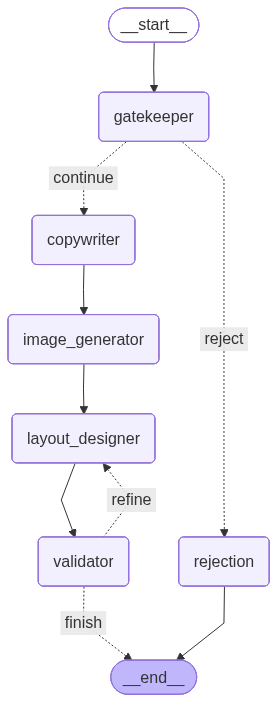

In [8]:
from IPython import display

display.Image(app.get_graph().draw_mermaid_png())

In [9]:
from PIL import Image, ImageDraw, ImageFilter
import os
def apply_algorithmic_scrim(bg_image_path: str, design: DesignLayout) -> str:
    """Bakes organic gradient scrims using high-speed Downsample Blurring."""
    if not os.path.exists(bg_image_path):
        return bg_image_path

    bg = Image.open(bg_image_path).convert("RGBA")
    img_w, img_h = bg.size
    scrim_layer = Image.new("RGBA", (img_w, img_h), (0, 0, 0, 0))
    draw = ImageDraw.Draw(scrim_layer)

    for element in design.elements:
        x1, y1, x2, y2 = get_bounding_box(element)
        pil_y1 = img_h - y2
        pil_y2 = img_h - y1

        pad = element.size * 1.5
        box = [x1 - pad, pil_y1 - pad, x2 + pad, pil_y2 + pad]
        fill_color = (255, 255, 255, 210) if element.color == '#000000' else (0, 0, 0, 210)
        draw.rectangle(box, fill=fill_color)

    # --- THE SPEED FIX: Downsample -> Blur -> Upsample ---
    # 1. Shrink the canvas by 4x
    small_w, small_h = img_w // 4, img_h // 4
    small_scrim = scrim_layer.resize((small_w, small_h), Image.Resampling.BILINEAR)

    # 2. Apply a 4x smaller blur (Mathematically instantaneous on CPU)
    fast_blur_radius = int((min(img_w, img_h) * 0.08) / 4)
    small_scrim = small_scrim.filter(ImageFilter.GaussianBlur(radius=fast_blur_radius))

    # 3. Scale back up smoothly
    scrim_layer = small_scrim.resize((img_w, img_h), Image.Resampling.LANCZOS)

    final_bg = Image.alpha_composite(bg, scrim_layer)
    scrimmed_path = bg_image_path.replace(".png", "_scrimmed.png")
    final_bg.convert("RGB").save(scrimmed_path, "PNG")

    return scrimmed_path

In [10]:
from PIL import Image, ImageDraw, ImageFilter
from reportlab.lib.colors import HexColor

import os

def apply_algorithmic_scrim(bg_image_path: str, design: DesignLayout) -> str:
    """Bakes organic gradient scrims directly into the background image."""
    if not os.path.exists(bg_image_path):
        return bg_image_path

    bg = Image.open(bg_image_path).convert("RGBA")
    img_w, img_h = bg.size
    scrim_layer = Image.new("RGBA", (img_w, img_h), (0, 0, 0, 0))
    draw = ImageDraw.Draw(scrim_layer)

    for element in design.elements:
        x1, y1, x2, y2 = get_bounding_box(element)

        # Convert PDF bottom-left origin to PIL top-left origin
        pil_y1 = img_h - y2
        pil_y2 = img_h - y1

        pad = element.size * 1.5
        box = [x1 - pad, pil_y1 - pad, x2 + pad, pil_y2 + pad]

        # Inverse scrim color: 82% opacity before blur
        fill_color = (255, 255, 255, 210) if element.color == '#000000' else (0, 0, 0, 210)
        draw.rectangle(box, fill=fill_color)

    # Dynamic blur radius ensures a smooth fade across any canvas size
    blur_radius = int(min(img_w, img_h) * 0.08)
    scrim_layer = scrim_layer.filter(ImageFilter.GaussianBlur(radius=blur_radius))

    final_bg = Image.alpha_composite(bg, scrim_layer)
    scrimmed_path = bg_image_path.replace(".png", "_scrimmed.png")
    final_bg.convert("RGB").save(scrimmed_path, "PNG")

    return scrimmed_path
# --- PDF Rendering Function (Local) ---

from reportlab.pdfgen import canvas

def render_pdf_locally(design: DesignLayout, output_path: str, bg_style: str, bg_hex: str):
    print(f"\n--- Rendering Vibrant Digital PDF: {output_path} ---")

    physical_width = design.width + (design.bleed_margin * 2)
    physical_height = design.height + (design.bleed_margin * 2)
    c = canvas.Canvas(output_path, pagesize=(physical_width, physical_height))

    # 1. Base Layer (Vibrant RGB colors restored)
    if bg_style in ['solid_color_with_photo', 'solid_color_text_only']:
        bg_hex = bg_hex.lstrip('#')
        r, g, b = tuple(int(bg_hex[i:i+2], 16) / 255.0 for i in (0, 2, 4))
        c.setFillColorRGB(r, g, b)
        c.rect(0, 0, physical_width, physical_height, fill=True, stroke=False)
    elif os.path.exists(design.background_image) and design.background_image != "none":
        safe_bg_path = apply_algorithmic_scrim(design.background_image, design)
        c.drawImage(safe_bg_path, 0, 0, width=physical_width, height=physical_height)

    # 2. Insert Layer
    if bg_style == 'solid_color_with_photo' and os.path.exists(design.background_image) and design.background_image != "none":
        img_w = int(design.width * 0.8)
        img_h = img_w
        img_x = (physical_width - img_w) / 2
        img_y = physical_height - img_h - 40 - design.bleed_margin
        c.drawImage(design.background_image, img_x, img_y, width=img_w, height=img_h, mask='auto')

    # 3. Typography Layer (Zoned Stacking)
    safe_x_min = design.bleed_margin + design.safe_zone_margin
    safe_x_max = physical_width - design.bleed_margin - design.safe_zone_margin

    # Group elements by their assigned vertical zone
    zones = {'top': [], 'middle': [], 'bottom': []}
    for el in design.elements:
        zones[el.vertical_zone].append(el)

    for zone_name, elements in zones.items():
        if not elements: continue

        # Calculate dynamic starting Y-positions for each zone
        if zone_name == 'top':
            current_y = physical_height - design.bleed_margin - design.safe_zone_margin - 40
        elif zone_name == 'bottom':
            # Calculate total block height to anchor from the bottom up
            total_h = sum([len(e.lines if e.lines else [e.text]) * (e.size * 1.2) for e in elements])
            current_y = design.bleed_margin + design.safe_zone_margin + total_h + 20
        else: # middle
            current_y = physical_height / 2 + 50

        for element in elements:
            if element.emphasis == 'script':
                element.font = 'Caveat-Bold'
                element.size = int(element.size * 1.8)

            try:
                pdfmetrics.getFont(element.font)
                c.setFont(element.font, element.size)
            except KeyError:
                c.setFont('Helvetica', element.size)

            lines_to_draw = element.lines if element.lines else [element.text]
            line_spacing = element.size * 1.2

            # Text Color (RGB)
            hex_color = element.color.lstrip('#')
            r, g, b = tuple(int(hex_color[i:i+2], 16)/255.0 for i in (0, 2, 4))
            if bg_style != 'full_image':
                c.setFillColorRGB(1, 1, 1) # White text on solid colors
            else:
                c.setFillColorRGB(r, g, b)

            # Adjust X for bleed and safe zones
            adjusted_x = element.x_pos + design.bleed_margin
            adjusted_x = max(safe_x_min, min(adjusted_x, safe_x_max))

            for line in lines_to_draw:
                y_shift = element.size * 0.4 if element.emphasis == 'script' else 0
                actual_y = current_y + y_shift

                if element.alignment == 'center':
                    c.drawCentredString(adjusted_x, actual_y, line)
                elif element.alignment == 'right':
                    c.drawRightString(adjusted_x, actual_y, line)
                else:
                    c.drawString(adjusted_x, actual_y, line)

                current_y -= line_spacing

    c.save()

import fitz  # PyMuPDF

def export_pdf_to_png(pdf_path: str, dpi: int = 300) -> str:
    """Rasterizes the vector PDF into a high-fidelity web-ready PNG."""
    print(f"--- Exporting Web-Ready PNG at {dpi} DPI ---")

    # Open the master PDF
    doc = fitz.open(pdf_path)
    page = doc.load_page(0)

    # Calculate the zoom matrix for the desired DPI (PDFs are natively 72 DPI)
    zoom = dpi / 72.0
    mat = fitz.Matrix(zoom, zoom)

    # Render the page to a pixel map
    pix = page.get_pixmap(matrix=mat, alpha=False)

    # Save as PNG
    png_path = pdf_path.replace(".pdf", ".png")
    pix.save(png_path)
    doc.close()

    print(f"Web Asset Saved: {png_path}")
    return png_path

In [11]:
# --- Orchestration ---
prompts = [
    # Prompt 1: The Flyer

    "Design a modern flyer for my coffee shop's grand opening on Saturday. VISUALS: A vibrant, highly detailed flat vector illustration of a steaming coffee cup sitting on a textured cafe table, surrounded by scattered coffee beans and warm sunbursts in the background. Use a bright, saturated orange, mustard yellow, and cream color palette. COPY FOCUS: Include '20% OFF'.",

    # Prompt 2: The Business Card
    "Create a business card for CanvasBot printing company. VISUALS: A vibrant, minimalist flat vector illustration of overlapping colorful paper sheets and abstract ink drops. Use a bright neon cyan, vivid magenta, sunshine yellow, and crisp white color palette. COPY: 'CanvasBot. Create. Print. Share.' LAYOUT: Set the text scale to standard.",

    # Prompt 3: The Poster
    "Generate a poster for my PhD presentation. VISUALS: A vibrant, modern 3D render of a glowing magnifying glass hovering over an open academic journal, using a bold teal and amber color palette. COPY: 'Thesis Dissertation. Dr. Edward L. Campbell'. LAYOUT: Place the text exactly in the middle of the canvas.",

    # Prompt 4: The Gatekeeper Trap
    "Can you design a book cover for my new sci-fi novel? The image should feature a dark, starry galaxy."
]

for prompt in prompts:
    print(f"\n\n{'='*60}\n--- Running Orchestration for: '{prompt}' ---\n{'='*60}")
    initial_state = AgentState(prompt=prompt, retry_count=0)
    final_state = app.invoke(initial_state)
    print("\n--- Orchestration Complete ---")

    if final_state.get('layout') and not final_state.get('validation_error') and final_state.get('design_category') != 'unsupported_style':
        output_path = f"generated_{final_state['design_category']}.pdf"

        # --- THE FIX: Extract the new background properties ---
        # Fallbacks added just in case the LLM dropped them
        bg_style = final_state['structured_copy'].background_style if final_state.get('structured_copy') else 'full_image'
        bg_hex = final_state['structured_copy'].background_hex if final_state.get('structured_copy') else '#FFFFFF'

        # Pass all 4 arguments to the renderer
        render_pdf_locally(final_state['layout'], output_path, bg_style, bg_hex)

        #Render to png
        export_pdf_to_png(output_path, dpi=300)

        if os.path.exists(final_state['image_path']) and final_state['image_path'] != "none":
            os.remove(final_state['image_path'])
    else:
        if final_state.get('design_category') == 'unsupported_style':
             print("\nSkipping PDF rendering because the design style is unsupported.")
        else:
             print("\nNo valid layout generated, skipping PDF rendering.")



--- Running Orchestration for: 'Design a modern flyer for my coffee shop's grand opening on Saturday. VISUALS: A vibrant, highly detailed flat vector illustration of a steaming coffee cup sitting on a textured cafe table, surrounded by scattered coffee beans and warm sunbursts in the background. Use a bright, saturated orange, mustard yellow, and cream color palette. COPY FOCUS: Include '20% OFF'.' ---
--- Running Gatekeeper Agent ---


/media/edwardl.campbell/D/code/CanvasBot/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GatekeeperResult(category='flyer'), input_type=GatekeeperResult])
  return self.__pydantic_serializer__.to_python(



--- Running Creative Director Agent ---


/media/edwardl.campbell/D/code/CanvasBot/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=CopywritingResult(backgro...ertical_zone='bottom')]), input_type=CopywritingResult])
  return self.__pydantic_serializer__.to_python(


Layout Style: solid_color_with_photo | Hex: #FCE572
Extracted Visuals: [illustration] vibrant_flat_vector_coffee_cup
Text: [TextBlock(role='headline', content='NEW COFFEE SHOP', emphasis='script', vertical_zone='top'), TextBlock(role='body', content='20% OFF', emphasis='none', vertical_zone='middle'), TextBlock(role='cta', content='OPEN SATURDAY', emphasis='none', vertical_zone='bottom')]

--- Running Smart Image Agent (Dynamic Prompting & Memory Safe) ---
Prompting SD: 'high quality  illustration of vibrant_flat_vector_coffee_cup, isolated on pure white background, studio lighting, clean'


...

  0%|          | 0/20 [00:00<?, ?it/s]

Isolating subject (Routing rembg to CPU to protect VRAM)...

--- Running Layout Agent ---


/media/edwardl.campbell/D/code/CanvasBot/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=DesignLayout(spatial_reas... Edward L. Campbell'])]), input_type=DesignLayout])
  return self.__pydantic_serializer__.to_python(



--- Running Smart Validator & Typography Math ---
Validation Result: PASSED (Typography Bounds Checked)
--- Routing to Finish ---

--- Orchestration Complete ---

--- Rendering Vibrant Digital PDF: generated_poster.pdf ---
--- Exporting Web-Ready PNG at 300 DPI ---
Web Asset Saved: generated_poster.png


--- Running Orchestration for: 'Can you design a book cover for my new sci-fi novel? The image should feature a dark, starry galaxy.' ---
--- Running Gatekeeper Agent ---

--- Request Rejected: The requested design category is not supported. Please request a 'flyer', 'poster', or 'business card'. ---

--- Orchestration Complete ---

Skipping PDF rendering because the design style is unsupported.


/media/edwardl.campbell/D/code/CanvasBot/.venv/lib/python3.12/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=GatekeeperResult(category='unsupported_style'), input_type=GatekeeperResult])
  return self.__pydantic_serializer__.to_python(
